# Eotvos correction

The Eotvos correction is a necessary correction to apply for any gravity surveys conducted on a moving platform, such as a ship or airplane. The correction accounts for the relative motion between the vehicle and the Earth's surface, which generates an additional centrifugal force known as the Eotvos effect. We offer several methods of computing the correction, which we show here, generally from simpliest to most complex.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is downloaded and subset in the notebook `AGAP_gravity_survey`. It has a pre-computed Eotvos correction, which we will compare our computed values to.

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey.csv")
print(data_df.columns)
data_df.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_filt,FAA_clip,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,49.38,49.38,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,49.45,49.45,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,49.52,49.52,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,49.58,49.58,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,49.65,49.65,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09


In [ ]:
survey = airbornegeo.Survey(
    data_df,
    line_column="line",
    distance_column="distance_along_line",
    time_column="unixtime",
    height_column="Height_WGS1984",
    latitude_column="Lat",
    longitude_column="Lon",
)
survey.along_track_distance()

In [ ]:
# get only the raw columns
# we will perform the corrections ourselves and compare to their values
survey.data = survey.data[
    [
        "EotvosCor",
        "Lon",
        "Lat",
        "Height_WGS1984",
        "easting",
        "northing",
        "unixtime",
        "line",
        "distance_along_line",
    ]
]
survey.data.head()

## Eotvos correction following Harlan 1968

Another common method to compute the correction is from [Harlan 1968](https://doi.org/10.1029/JB073i014p04675). The paper offers several equations, but first we will follow equation 15. 

### Equation 15:
This formulation requires the aircraft latitude, longtide, time (to calculate time derivatives) and height. 

```math
E = \frac{V_N^2}{a} [ 1 + \frac{h}{a} + f (2-3\sin^{2}\phi) ] + \frac{V_E^2}{a} [ 1 + \frac{h}{a} - f \sin^{2}\phi) ] + 2 V_E \omega \cos \phi (1 + \frac{h}{a})
```
where $V_N$, $V_E$, $h$, and $\phi$, $ are the aircraft's eastward and northward velocities, height, and geodetic latitude, and $a$, $f$, and $\omega$ are the ellipsoid's semimajor axis, flattening, and rotation rate.

```math
V_N = r' \dot{\phi_{c}} sec(D)
```
```math
V_E = r' \dot{l} cos(\phi_{c})
```

where $r'$ is the ellipsoid's geocentric radius at the latitude of the aircraft, $l$ is the aircraft's longitude, $\phi_{c}$ is the geocentric radius of the aircraft, $\dot{\phi_{c}}$ is the first time derivative of the geocentric radius of the aircraft, and $D$ is the deviation between the aircraft's geodetic latitude and geocentric latitude. 

Compared to the Glicken formulation, it is more exact since it accounts for aircraft height as well as the flattening of the ellipsoid. However it still makes a few assumptions which simplify the calculations. These include a simplification for the deviation between geocentric and geodetic latitudes, and thus the time derivatives of this deviation, as well as a simplification of the geocentric radius, and thus the time derivatives of the geocentric radius.

In [ ]:
survey.eotvos_correction(
    method="harlan",
    result_column="eotvos_correction_harlan",
)
survey.data.head()

In [ ]:
ax = survey.data.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_harlan",
    s=0.2,
)
ax.set_aspect("equal")

In [ ]:
df = survey.data[survey.data.line == 4]
ylim = vd.minmax(df.EotvosCor)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_harlan",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

## Full Eotvos correction

The above methods used some assumptions to simplify the complex calculation for the Eotvos Correction. Below, we demonstrate the full analytic solution to the Eotvos correction equation. These methods utilize the 2nd temporal derivative of quantities such as latitude, longitude, and height, making them highly sensitive. If the data has been downsampled, the results will likely be skewed. 

In [ ]:
survey.eotvos_correction(
    method="full",
    result_column="eotvos_correction_full",
)
survey.data.head()

In [ ]:
ax = survey.data.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_full",
    s=0.2,
)
ax.set_aspect("equal")

In [ ]:
df = survey.data[survey.data.line == 4]
# ylim = vd.minmax(df.EotvosCor)
ylim = vd.minmax(df.eotvos_correction_full)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_full",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

In [ ]:
survey.eotvos_correction(
    method="approx",
    result_column="eotvos_correction_approx",
)
survey.data.head()

In [ ]:
ax = survey.data.plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction_approx",
    s=0.2,
)
ax.set_aspect("equal")

In [ ]:
df = survey.data[survey.data.line == 4]
# ylim = vd.minmax(df.EotvosCor)
ylim = vd.minmax(df.eotvos_correction_approx)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="bp",
    ms=0.6,
    label="Published values",
    title=f"Line {df.line.unique()[0]}",
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_approx",
    style="rp",
    ms=0.6,
    title=f"Line {df.line.unique()[0]}",
    label="Calculated values",
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("Eotvos correction (mGal)")

In [ ]:
df = survey.data[survey.data.line == 4]
df = df[df.distance_along_line < 140e3]
df = airbornegeo.resample(
    df,
    spacing=0.1,
    resample_by="unixtime",
    maxdist=10,
)
df.head()

In [15]:
df.unixtime.iloc[0], df.unixtime.iloc[1]

(np.float64(1230569566.0), np.float64(1230569566.1))

In [16]:
# from https://www.boulama.com/blog/posts/smoothing-noisy-sensor-data-with-kalman-filters.html
class KalmanFilter:
    def __init__(self, process_variance, measurement_variance):
        self.process_variance = process_variance
        self.measurement_variance = measurement_variance
        self.posteri_estimate = 0.0
        self.posteri_error_estimate = 1.0

    def update(self, measurement):
        priori_estimate = self.posteri_estimate
        priori_error_estimate = self.posteri_error_estimate + self.process_variance

        blending_factor = priori_error_estimate / (
            priori_error_estimate + self.measurement_variance
        )
        self.posteri_estimate = priori_estimate + blending_factor * (
            measurement - priori_estimate
        )
        self.posteri_error_estimate = (1 - blending_factor) * priori_error_estimate

        return self.posteri_estimate

,EotvosCor,Lon,Lat,Height_WGS1984,easting,northing,unixtime,line,distance_along_line,eotvos_correction_harlan,eotvos_correction_full,eotvos_correction_approx
0,42.470000,73.409641,-77.410237,3574.500000,1.316050e+06,392090.546753,1.230570e+09,4,0.000000,42.363382,0.932149,5042.340589
1,42.467111,73.409616,-77.410293,3574.487211,1.316044e+06,392089.356822,1.230570e+09,4,6.166673,42.362523,2.304246,5260.720469
2,42.464144,73.409592,-77.410349,3574.472565,1.316038e+06,392088.166589,1.230570e+09,4,12.331705,42.361829,4.068619,5431.191035
3,42.461120,73.409568,-77.410404,3574.456159,1.316032e+06,392086.976092,1.230570e+09,4,18.495250,42.361322,5.737565,5553.519274
4,42.458059,73.409543,-77.410460,3574.438087,1.316026e+06,392085.785359,1.230570e+09,4,24.657521,42.361022,7.311113,5627.473567


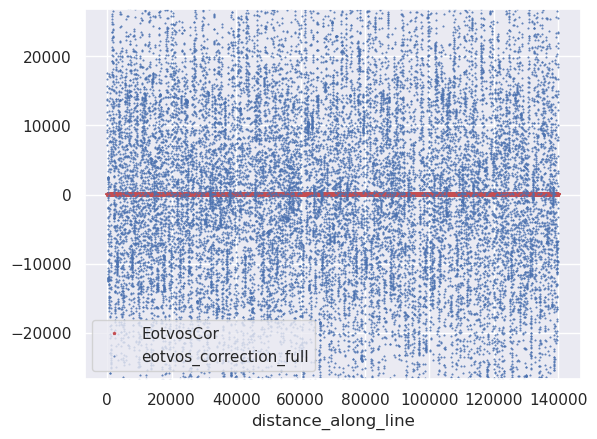

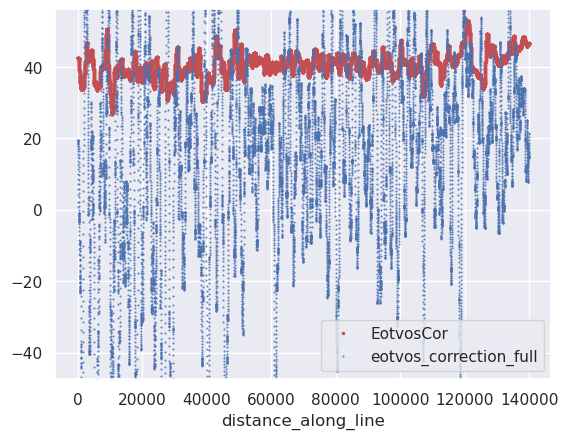

In [17]:
df["eotvos_correction_full"] = airbornegeo.eotvos_correction(
    df,
    method="full",
    latitude_column="Lat",
    longitude_column="Lon",
    time_column="unixtime",
    height_column="Height_WGS1984",
)

ylim = vd.minmax(
    df["eotvos_correction_full"],
    min_percentile=5,
    max_percentile=95,
)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="rp",
    ms=1.6,
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_full",
    style="bp",
    ms=0.4,
    ax=ax,
    ylim=ylim,
)

# df['eotvos_correction_full'] = sp.signal.savgol_filter(
#     x=df.eotvos_correction_full,
#     window_length=1000,
#     polyorder=2,
# )
# df['eotvos_correction_full'] = sp.signal.savgol_filter(
#     x=df.eotvos_correction_full,
#     window_length=1000,
#     polyorder=2,
# )
# df['eotvos_correction_full'] = sp.signal.savgol_filter(
#     x=df.eotvos_correction_full,
#     window_length=1000,
#     polyorder=2,
# )

# df['eotvos_correction_full'] = sp.signal.wiener(
#     df.eotvos_correction_full,
#     mysize=2001,
# )
# df['eotvos_correction_full'] = sp.signal.wiener(
#     df.eotvos_correction_full,
#     mysize=2001,
# )
# df['eotvos_correction_full'] = sp.signal.wiener(
#     df.eotvos_correction_full,
#     mysize=2001,
# )
# df['eotvos_correction_full'] = airbornegeo.filter_line(
#     df,
#     filter_width=1000,
#     filter_type="lowpass",
#     data_column='eotvos_correction_full',
#     filter_by_column="unixtime",
#     # pad_mode="linear_ramp",
#     pad_width_percentage=100,
# )
# df['eotvos_correction_full'] = airbornegeo.filter_line(
#     df,
#     filter_width=1000,
#     filter_type="lowpass",
#     data_column='eotvos_correction_full',
#     filter_by_column="unixtime",
#     # pad_mode="linear_ramp",
#     pad_width_percentage=100,
# )


kalman = KalmanFilter(
    process_variance=0.0000001,
    measurement_variance=10000,
)

# Apply Kalman filter
df["eotvos_correction_full"] = [
    kalman.update(measurement) for measurement in df.eotvos_correction_full
]


ylim = vd.minmax(
    df["eotvos_correction_full"],
    min_percentile=5,
    max_percentile=95,
)
ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="rp",
    ms=1.6,
    ylim=ylim,
)
ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction_full",
    style="bp",
    ms=0.4,
    ax=ax,
    ylim=ylim,
)
df.head()